In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime, os
from scipy.signal import decimate
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

In [26]:
BASE = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

F_MIX_FILES = [
    "aprbs-1_0827_17-19.csv", "aprbs-2_0827_17-25.csv", "aprbs-3_0827_17-28.csv", "aprbs-4_0827_17-31.csv",
    "multi-seno-1_0827_17-34.csv", "multi-seno-2_0827_17-37.csv", "multi-seno-3_0827_17-40.csv", "multi-seno-4_0827_17-43.csv",
    "swept-sine-1_0827_17-58.csv", "swept-sine-4_0827_18-00.csv",
    "seq-degraus-1_0827_17-46.csv", "seq-degraus-2_0827_17-49.csv", "seq-degraus-3_0827_17-52.csv", "seq-degraus-4_0827_17-55.csv",
    "RODADA-3/chirp-1_0807_16-34.csv", "RODADA-3/chirp-2_0807_17-07.csv", "RODADA-3/chirp-2_0807_17-09.csv"
]

TEST_FILES_BY_TYPE = {
    "APRBS":     "RODADA-4/aprbs-2_0819_18-51.csv",
    "MultiSeno": "RODADA-2/multi-seno-1_0804_19-06.csv",
    "SweptSine": "RODADA-4/swept-sine-1_0819_19-02.csv",
    "Degraus":   "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "Chirp":     "RODADA-2/chirp-1_0804_19-19.csv",
}

DECIMACAO = 2
START_IDX = 200
END_IDX   = -200

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[-100], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[180.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-180.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[360.]
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,2
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](1,)",[0.01]


In [27]:
def carregar_experimento(url, decimacao=DECIMACAO, start_idx=START_IDX, end_idx=END_IDX):
    df = pd.read_csv(url)
    if 'referencia' in df.columns:
        df = df[df['referencia'] > 0]
    u_full = df['u_pct'].values.astype(np.float64) if 'u_pct' in df.columns else df['motor_percent'].values.astype(np.float64)
    y_full = df['angulo_deg'].values.astype(np.float64)
    
    if decimacao > 1:
        y_raw = decimate(y_full, decimacao, ftype='iir', zero_phase=True)
        u_raw = u_full[::decimacao]
    else:
        u_raw, y_raw = u_full, y_full
        
    dt = 0.010 * decimacao
    t_raw = np.arange(len(y_raw)) * dt
    min_l = min(len(y_raw), len(u_raw))
    t_raw, u_raw, y_raw = t_raw[:min_l], u_raw[:min_l], y_raw[:min_l]
    
    if start_idx is not None and end_idx is not None:
        t_raw = t_raw[start_idx:end_idx]
        u_raw = u_raw[start_idx:end_idx]
        y_raw = y_raw[start_idx:end_idx]
        
    t_raw = t_raw - t_raw[0]
    return t_raw, u_raw, y_raw

def processar_dataset(t_raw, u_raw, y_raw):
    u_norm = scaler_u.transform(u_raw.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()
    return t_raw, u_norm, y_norm, u_raw, y_raw

def carregar_lista(file_list):
    datasets = []
    for f in file_list:
        t, u_raw, y_raw = carregar_experimento(BASE + f)
        t, u_norm, y_norm, _, _ = processar_dataset(t, u_raw, y_raw)
        datasets.append({
            'name': os.path.basename(f),
            't': t, 'u_norm': u_norm, 'y_norm': y_norm,
            'u_raw': u_raw, 'y_raw': y_raw
        })
    return datasets

In [28]:
print("Carregando dataset misto (F_Mix) de treinamento...")
train_datasets = carregar_lista(F_MIX_FILES)

print("\nCarregando conjuntos de Teste (Cross-Session)...")
test_datasets = []
for tipo, arquivo in TEST_FILES_BY_TYPE.items():
    test_datasets.extend(carregar_lista([arquivo]))

Carregando dataset misto (F_Mix) de treinamento...

Carregando conjuntos de Teste (Cross-Session)...


In [29]:
def create_regression_matrix(u, y, na, nb):
    u = np.asarray(u).flatten()
    y = np.asarray(y).flatten()
    N = len(y)
    p = max(na, nb)
    y_target = y[p:]
    Phi = np.zeros((N - p, na + nb))
    for i in range(1, na + 1):
        Phi[:, i - 1] = -y[p - i: N - i]
    for i in range(1, nb + 1):
        Phi[:, na + i - 1] = u[p - i: N - i]
    return Phi, y_target

def build_combined_matrices(datasets, na, nb, use_norm=True):
    Phi_all = []
    y_all = []
    for ds in datasets:
        u_data = ds['u_norm'] if use_norm else ds['u_raw']
        y_data = ds['y_norm'] if use_norm else ds['y_raw']
        Phi, y_target = create_regression_matrix(u_data, y_data, na, nb)
        Phi_all.append(Phi)
        y_all.append(y_target)
    return np.vstack(Phi_all), np.concatenate(y_all)

def free_run_simulation(th_hat, u, y_measured, na, nb):
    u = np.asarray(u).flatten()
    y_measured = np.asarray(y_measured).flatten()
    N = len(u)
    p = max(na, nb)
    y_sim = np.zeros(N)
    y_sim[:p] = y_measured[:p]
    
    for k in range(p, N):
        u_window = u[k-p : k+1]
        y_window = y_sim[k-p : k+1]
        Phi_k_matrix, _ = create_regression_matrix(u_window, y_window, na, nb)
        y_sim[k] = Phi_k_matrix[0] @ th_hat
        
    return y_sim[p:]

In [ ]:
# Lista de ordens a testar. 
ordens_teste = [

    (1000, 1000), (2000, 2000), (2500, 2500), (3000, 3000), (3500, 3500)
]

resultados = []
use_norm = True # Usando os dados normalizados como feito no NARX_POLINOMIAL

print("\n--- INICIANDO BUSCA DE MELHORES ORDENS (na, nb) ---")
for na_t, nb_t in ordens_teste:
    print(f"Testando na={na_t}, nb={nb_t}...")
    Phi_tra, y_tra = build_combined_matrices(train_datasets, na_t, nb_t, use_norm)
    
    # Estimação usando Mínimos Quadrados (BLS)
    th_t, _, _, _ = np.linalg.lstsq(Phi_tra, y_tra, rcond=None)
    
    # Avaliação no Treinamento (One Step Ahead)
    osa_tra = Phi_tra @ th_t
    r2_osa_tra = r2_score(y_tra, osa_tra)
    rmse_osa_tra = np.sqrt(mean_squared_error(y_tra, osa_tra))
    
    # Free-Run no Treino (Calculando a média dos R2 de cada experimento)
    r2_fr_tra_list = []
    rmse_fr_tra_list = []
    for ds in train_datasets:
        u_data = ds['u_norm'] if use_norm else ds['u_raw']
        y_data = ds['y_norm'] if use_norm else ds['y_raw']
        fr_sim = free_run_simulation(th_t, u_data, y_data, na_t, nb_t)
        y_real_valid = y_data[max(na_t, nb_t):]
        r2_fr_tra_list.append(r2_score(y_real_valid, fr_sim))
        rmse_fr_tra_list.append(np.sqrt(mean_squared_error(y_real_valid, fr_sim)))
        
    r2_fr_tra_mean = np.mean(r2_fr_tra_list)
    rmse_fr_tra_mean = np.mean(rmse_fr_tra_list)
    
    # Avaliação no Teste (Validação)
    r2_fr_tst_list = []
    rmse_fr_tst_list = []
    for ds in test_datasets:
        u_data = ds['u_norm'] if use_norm else ds['u_raw']
        y_data = ds['y_norm'] if use_norm else ds['y_raw']
        fr_sim = free_run_simulation(th_t, u_data, y_data, na_t, nb_t)
        y_real_valid = y_data[max(na_t, nb_t):]
        r2_fr_tst_list.append(r2_score(y_real_valid, fr_sim))
        rmse_fr_tst_list.append(np.sqrt(mean_squared_error(y_real_valid, fr_sim)))
        
    r2_fr_tst_mean = np.mean(r2_fr_tst_list)
    rmse_fr_tst_mean = np.mean(rmse_fr_tst_list)

    resultados.append({
        'na': na_t, 'nb': nb_t,
        'RMSE_OSA_TRA': rmse_osa_tra,
        'R2_OSA_TRA':   r2_osa_tra,
        'RMSE_FR_TRA':  rmse_fr_tra_mean,
        'R2_FR_TRA':    r2_fr_tra_mean,
        'RMSE_FR_TST':  rmse_fr_tst_mean,
        'R2_FR_TST':    r2_fr_tst_mean,
    })


--- INICIANDO BUSCA DE MELHORES ORDENS (na, nb) ---
Testando na=1000, nb=1000...
Testando na=2000, nb=2000...
Testando na=2500, nb=2500...


In [ ]:
df_res = pd.DataFrame(resultados)
print("\n--- RESULTADOS FINAIS ---")
print(df_res.to_string(index=False, float_format="{:.4f}".format))

best = df_res.loc[df_res['R2_FR_TST'].idxmax()]
print(f"\nMelhor configuração (R² Free-Run Médio na Validação): na={int(best.na)}, nb={int(best.nb)}")
print(f"  TRA → RMSE_FR={best.RMSE_FR_TRA:.4f}  R²_FR={best.R2_FR_TRA:.4f}")
print(f"  TST → RMSE_FR={best.RMSE_FR_TST:.4f}  R²_FR={best.R2_FR_TST:.4f}")


--- RESULTADOS FINAIS ---
  na   nb  RMSE_OSA_TRA  R2_OSA_TRA  RMSE_FR_TRA  R2_FR_TRA  RMSE_FR_TST  R2_FR_TST
  80   80        0.0001      1.0000       0.1092     0.4501       0.0862     0.5899
 100  100        0.0001      1.0000       0.1090     0.4491       0.0870     0.5814
 120  120        0.0001      1.0000       0.1089     0.4573       0.0866     0.5880
  30   10        0.0001      1.0000       0.1315     0.2360       0.1109     0.3026
  10   30        0.0001      1.0000       0.1154     0.3768       0.1003     0.4120
  50   20        0.0001      1.0000       0.1160     0.3947       0.0991     0.4432
  20   50        0.0001      1.0000       0.1154     0.3637       0.0980     0.4386
 200  200        0.0001      1.0000       0.1075     0.4806       0.0863     0.6071
 300  300        0.0001      1.0000       0.1080     0.4806       0.0871     0.6160
 500  500        0.0001      1.0000       0.1056     0.5212       0.0881     0.6289
1000 1000        0.0001      1.0000       0.1035 

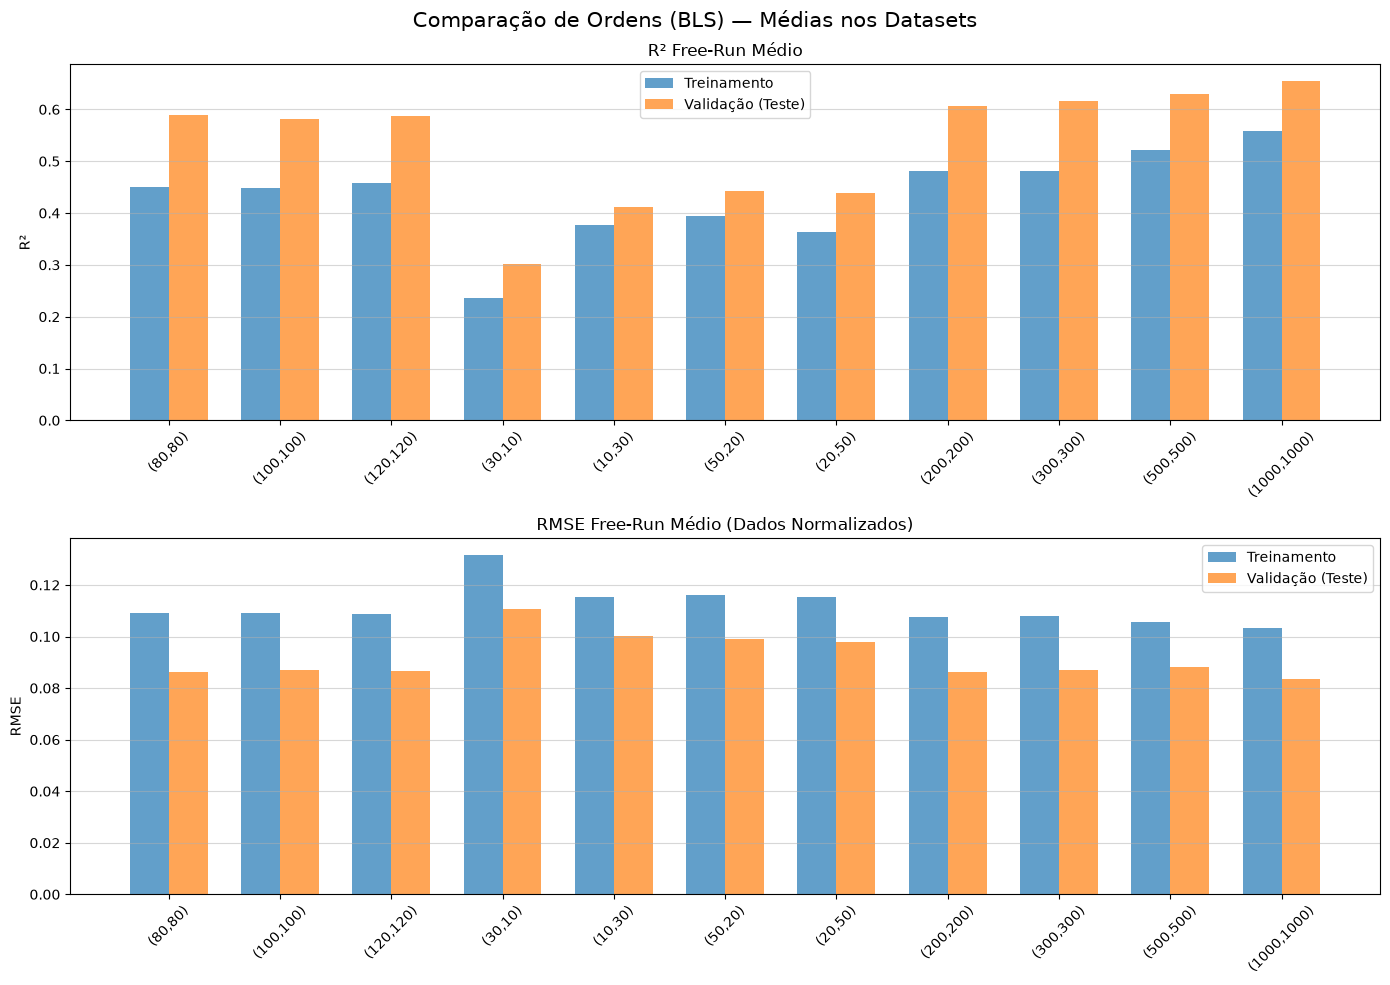

In [ ]:
labels = [f"({int(r.na)},{int(r.nb)})" for r in df_res.itertuples()]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Comparação de Ordens (BLS) — Médias nos Datasets', fontsize=15)

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, df_res['R2_FR_TRA'], width, label='Treinamento', alpha=0.7)
axes[0].bar(x + width/2, df_res['R2_FR_TST'], width, label='Validação (Teste)', alpha=0.7)
axes[0].set_title('R² Free-Run Médio')
axes[0].set_ylabel('R²')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].grid(axis='y', alpha=0.5)
axes[0].legend()

axes[1].bar(x - width/2, df_res['RMSE_FR_TRA'], width, label='Treinamento', alpha=0.7)
axes[1].bar(x + width/2, df_res['RMSE_FR_TST'], width, label='Validação (Teste)', alpha=0.7)
axes[1].set_title('RMSE Free-Run Médio (Dados Normalizados)')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].grid(axis='y', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()